In [1]:
%%capture
!pip install -q chronos-forecasting huggingface_hub

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import os
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from chronos import ChronosBoltPipeline
import seaborn as sns
from sklearn.metrics import mean_squared_error


DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device {DEVICE}')
print(f'torch {torch.__version__}')

device cuda
torch 2.10.0+cu128


In [175]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

In [176]:
FT_MODEL_DIR  = '/kaggle/working/chronos_bbca_ft'
HF_REPO_ID    = 'SkibidiBreaddd/BBCA-Chronos-14062026-v0'

In [177]:
path ='/kaggle/input/datasets/muamkh/ihsgstockdata/daily/BBCA.csv'
raw = pd.read_csv(path)
raw.head()

,timestamp,open,low,high,close,volume
0,2001-04-16,175,175,180,177,0
1,2001-04-17,175,175,180,177,0
2,2001-04-18,175,175,180,177,0
3,2001-04-19,175,175,180,177,0
4,2001-04-20,175,175,180,177,0


In [178]:
raw_1 = raw.copy()
raw_1['date']=pd.to_datetime(raw_1['timestamp'], format='%Y-%m-%d')
raw_1 = raw_1.set_index('date')
raw_1.head()

,timestamp,open,low,high,close,volume
date,,,,,,
2001-04-16,2001-04-16,175,175,180,177,0
2001-04-17,2001-04-17,175,175,180,177,0
2001-04-18,2001-04-18,175,175,180,177,0
2001-04-19,2001-04-19,175,175,180,177,0
2001-04-20,2001-04-20,175,175,180,177,0


In [179]:
df=raw_1.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5670 entries, 2001-04-16 to 2023-01-06
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   timestamp  5670 non-null   object
 1   open       5670 non-null   int64 
 2   low        5670 non-null   int64 
 3   high       5670 non-null   int64 
 4   close      5670 non-null   int64 
 5   volume     5670 non-null   int64 
dtypes: int64(5), object(1)
memory usage: 310.1+ KB


In [180]:
df.describe()

,open,low,high,close,volume
count,5670.000000,5670.000000,5670.000000,5670.000000,5.670000e+03
mean,2418.109877,2393.385538,2442.639506,2418.603175,8.919048e+07
std,2379.071545,2357.118837,2400.150856,2378.798150,1.274925e+08
min,175.000000,175.000000,177.000000,177.000000,0.000000e+00
25%,460.000000,455.000000,467.000000,460.500000,2.719000e+07
50%,1585.000000,1570.000000,1600.000000,1585.000000,6.161450e+07
75%,3743.750000,3715.000000,3765.000000,3740.000000,1.045481e+08
max,9050.000000,8975.000000,9400.000000,9300.000000,1.949960e+09


In [181]:
df.isnull().sum()

timestamp    0
open         0
low          0
high         0
close        0
volume       0
dtype: int64

In [182]:
df.duplicated().sum()

np.int64(0)

In [183]:
df =df.sort_index()

In [184]:
start_date = df.iloc[0,:]
end_date = df.iloc[-1,:]

print(start_date)
print(end_date)

timestamp    2001-04-16
open                175
low                 175
high                180
close               177
volume                0
Name: 2001-04-16 00:00:00, dtype: object
timestamp    2023-01-06
open               8100
low                8100
high               8325
close              8300
volume         69286600
Name: 2023-01-06 00:00:00, dtype: object


### Close Price

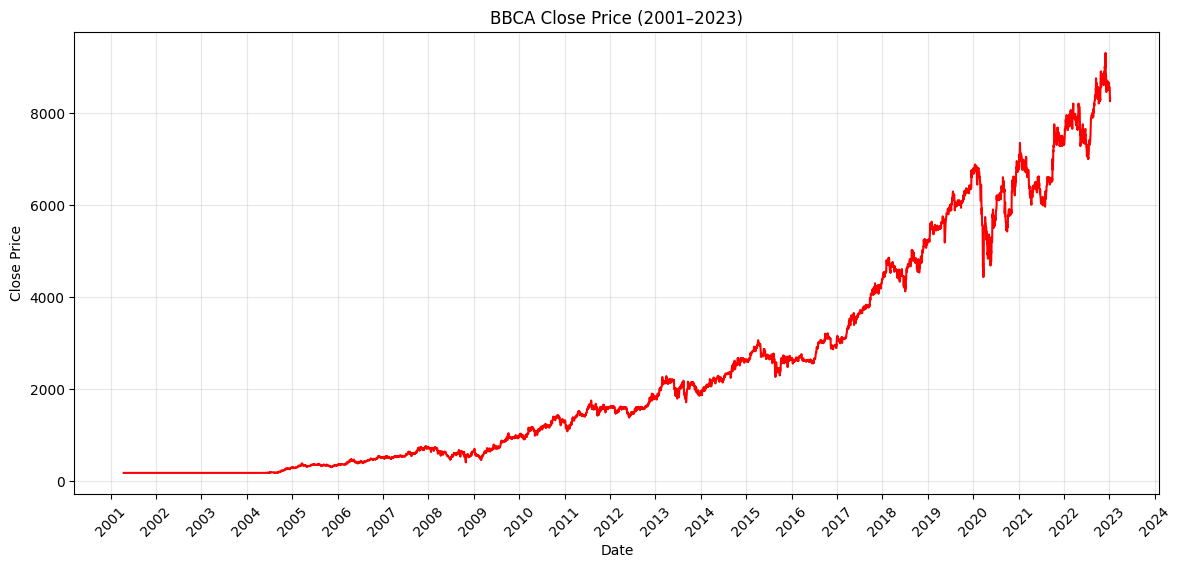

In [185]:
plt.figure(figsize=(14,6))
plt.plot(df["close"], color='red')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator()) 
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.title("BBCA Close Price (2001–2023)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

### Moving Average and Rolling Mean

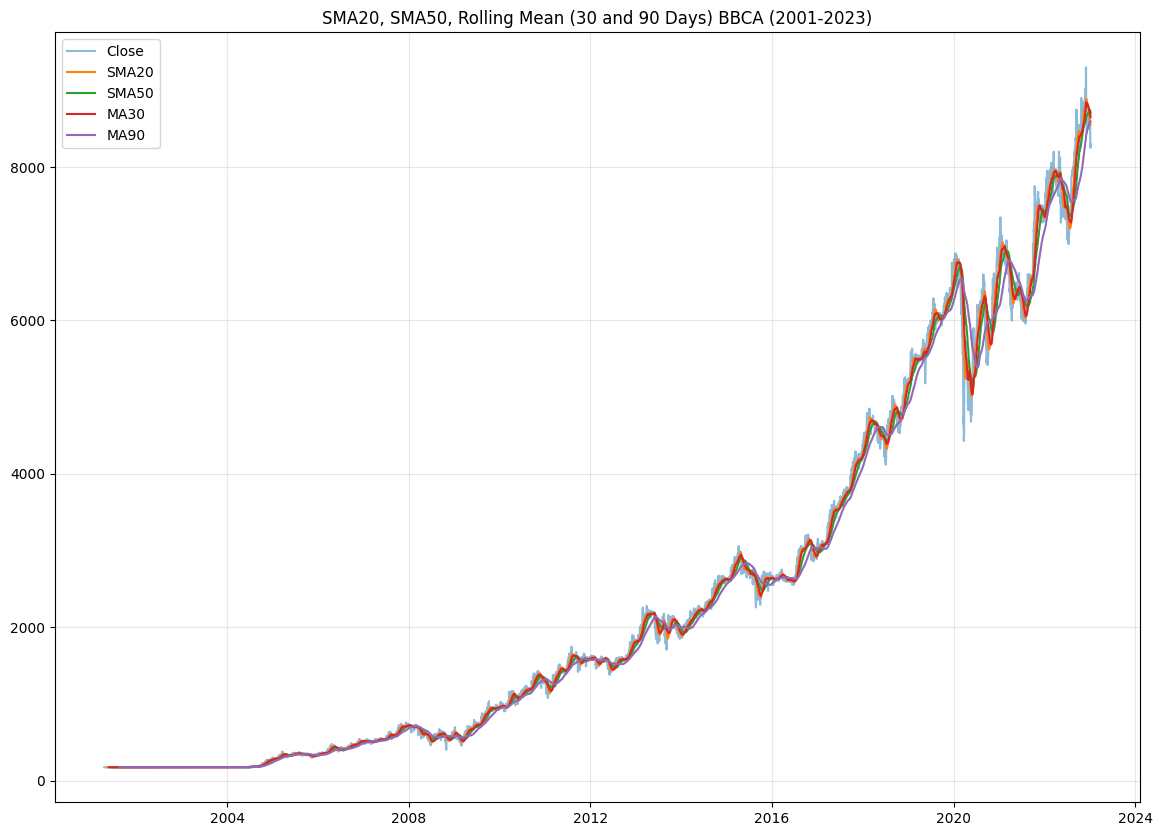

In [186]:
df["SMA20"] = df["close"].rolling(20).mean()
df["SMA50"] = df["close"].rolling(50).mean()
df["rolling_30"] = df["close"].rolling(30).mean()
df["rolling_90"] = df["close"].rolling(90).mean()

plt.figure(figsize=(14, 10))
plt.plot(df["close"], alpha=0.5)
plt.plot(df["SMA20"])
plt.plot(df["SMA50"])
plt.plot(df["rolling_30"])
plt.plot(df["rolling_90"])
plt.title("SMA20, SMA50, Rolling Mean (30 and 90 Days) BBCA (2001-2023)")
plt.legend(["Close", "SMA20", "SMA50","MA30", "MA90"])
plt.grid(alpha=0.3)

### Volume

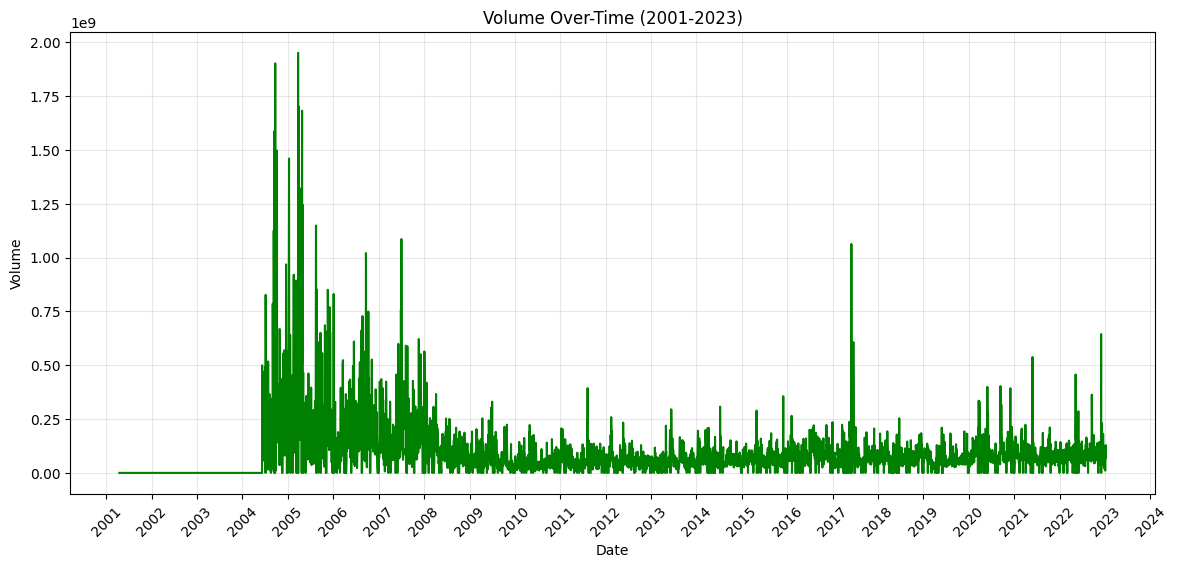

In [187]:
plt.figure(figsize=(14, 6))
plt.plot(df["volume"], color='green')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator()) 
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.title("Volume Over-Time (2001-2023)")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

### Volatility

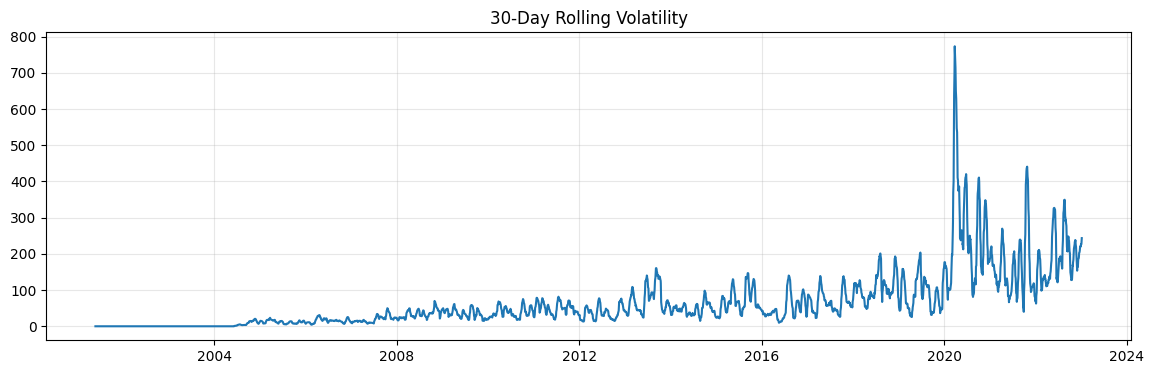

In [188]:
df["volatility_30"] = df["close"].rolling(30).std()

plt.figure(figsize=(14, 4))
plt.plot(df["volatility_30"])
plt.title("30-Day Rolling Volatility")
plt.grid(alpha=0.3)

### Return and Distribution

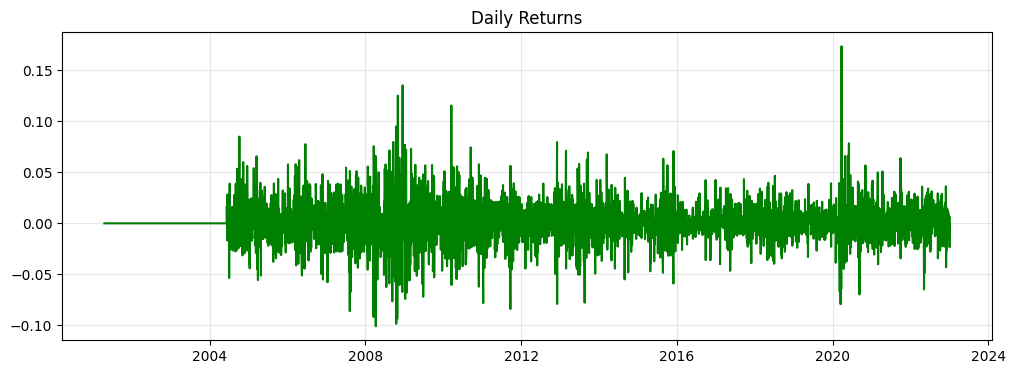

In [189]:
df["returns"] = df["close"].pct_change()
df["log_returns"] = np.log(df["close"] / df["close"].shift(1))

plt.figure(figsize=(12, 4))
plt.plot(df['returns'], color='green')
plt.title("Daily Returns")
plt.grid(alpha=0.3)

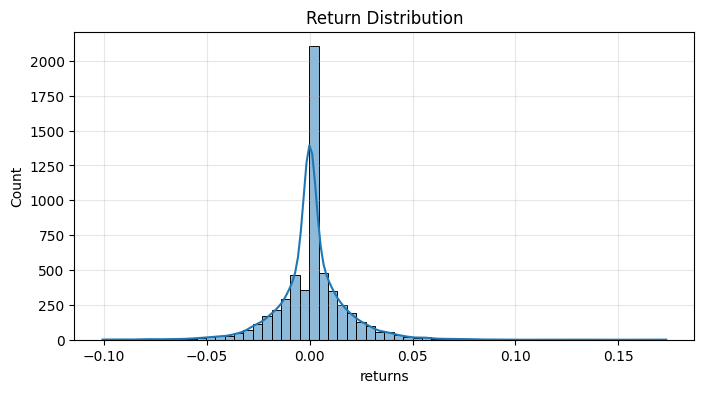

In [37]:
plt.figure(figsize=(8, 4))
sns.histplot(df["returns"], bins=60, kde=True)
plt.title("Return Distribution")
plt.grid(alpha=0.3)

## Model Testing amazon/chronos-bolt-small

In [223]:
df = raw.copy()
df = df.sort_values('timestamp').reset_index(drop=True)
df.head()

,timestamp,open,low,high,close,volume
0,2001-04-16,175,175,180,177,0
1,2001-04-17,175,175,180,177,0
2,2001-04-18,175,175,180,177,0
3,2001-04-19,175,175,180,177,0
4,2001-04-20,175,175,180,177,0


In [224]:
df['close'] = np.log(df['close'])

In [225]:
cut           = len(df) - HORIZON
train_df      = df.iloc[:cut].copy()
test_df       = df.iloc[cut:].copy()
cutoff_date = pd.to_datetime(train_df.timestamp.iloc[-1])

In [226]:
MODEL_ID      = 'amazon/chronos-bolt-small'
CONTEXT       = 512      
HORIZON       = 5     
BATCH_SIZE    = 32
N_VAL_WINDOWS = 5

In [227]:
# val
# val_cut       = len(train_df) - HORIZON
# val_context   = train_df.close.values[val_cut - CONTEXT : val_cut]
# val_target    = train_df.close.values[val_cut : val_cut + HORIZON]

In [228]:
#arr
close_all     = df.close.values.astype(np.float32)
close_train   = train_df.close.values.astype(np.float32)
val_windows = []
for i in range(N_VAL_WINDOWS):
    end   = len(train_df) - i * HORIZON
    start = end - CONTEXT
    if start < 0:
        break
    ctx = close_train[start:end]
    tgt = close_train[end:end + HORIZON]
    val_windows.append((ctx, tgt))

print(f'Validation windows : {len(val_windows)}')

Validation windows : 5


In [229]:
print(f'train : {len(train_df)}')
print(f'test : {len(test_df)}')
print(f'train cutoff : {cutoff_date.date()}')

train : 5665
test : 5
train cutoff : 2022-12-30


### Sliding Window

In [230]:
class SlidingWindowDataset(Dataset):
    """
    Each sample: context window of length CONTEXT, target of length HORIZON.
    Sliding stride of 1 to maximise training signal on a small series.
    """
    def __init__(self, series: np.ndarray, context: int, horizon: int):
        self.series  = torch.tensor(series, dtype=torch.float32)
        self.context = context
        self.horizon = horizon
        self.n       = len(series) - context - horizon + 1
        assert self.n > 0, 'Series too short for given context + horizon'

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        x = self.series[idx : idx + self.context]
        y = self.series[idx + self.context : idx + self.context + self.horizon]
        return x, y


dataset    = SlidingWindowDataset(close_train, CONTEXT, HORIZON)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                        drop_last=False, num_workers=0)
print(f'Training windows : {len(dataset)}')

Training windows : 5149


### Load Pre-Trained Model

In [231]:
pipeline = ChronosBoltPipeline.from_pretrained(
    MODEL_ID,
    device_map=DEVICE,
    torch_dtype=torch.float32,
)
model = pipeline.model
print(f'context_length : {model.chronos_config.context_length}')
print(f'prediction length : {model.chronos_config.prediction_length}')
print(f'Parameters : {sum(p.numel() for p in model.parameters()):,}')

context_length : 2048
prediction length : 64
Parameters : 47,718,016


## Zero-Shot

In [232]:
def run_inference(pipeline, context_series: np.ndarray, horizon: int) -> np.ndarray:
    """Return median (0.5 quantile) forecast as numpy array."""
    ctx = torch.tensor(context_series, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        preds = pipeline.predict(ctx, prediction_length=horizon)  # (1, Q, horizon)
    # median = quantile index 4 for 9-quantile Chronos-Bolt
    median_idx = pipeline.model.chronos_config.quantiles.index(0.5) \
        if hasattr(pipeline.model.chronos_config, 'quantiles') else 4
    return preds[0, median_idx, :].cpu().numpy()


def compute_metrics(pred: np.ndarray, actual: np.ndarray) -> dict:
    pred = np.exp(pred)
    actual = np.exp(actual)
    mae  = float(np.mean(np.abs(pred - actual)))
    rmse = float(np.sqrt(np.mean((pred - actual) ** 2)))
    mape = float(np.mean(np.abs((pred - actual) / actual)) * 100)
    naive_mae = float(np.mean(np.abs(np.diff(np.exp(close_train)))))
    mase = mae / naive_mae if naive_mae > 0 else np.nan
    return {'MAE': mae, 'RMSE': rmse, 'MAPE(%)': mape, 'MASE': mase}


# context = last CONTEXT rows of train
test_context   = close_train[-CONTEXT:]
test_actual    = test_df.close.values.astype(np.float32)

baseline_pred  = run_inference(pipeline, test_context, HORIZON)
baseline_metrics = compute_metrics(baseline_pred, test_actual)

print('Baseline (zero-shot) metrics:')
for k, v in baseline_metrics.items():
    print(f'  {k:10s}: {v:.4f}')

Baseline (zero-shot) metrics:
  MAE       : 208.5338
  RMSE      : 253.6156
  MAPE(%)   : 2.5089
  MASE      : 8.3718


model isnt able to predict and comprehend the data. Chronos was pre-trained on normalized, diverse datasets and has never seen Indonesian equities.

### Finetune Model on Training Data

In [247]:
LR            = 1e-4
MAX_STEPS     = 3500
VAL_EVERY     = 50       
PATIENCE      = 15        
GRAD_CLIP     = 0.7

In [248]:
# def validate(model, val_context: np.ndarray, val_target: np.ndarray) -> float:
#     """Pinball loss on validation window (quantile regression loss used by Chronos-Bolt)."""
#     model.eval()
#     with torch.no_grad():
#         ctx = torch.tensor(val_context, dtype=torch.float32).unsqueeze(0).to(DEVICE)
#         tgt = torch.tensor(val_target,  dtype=torch.float32).unsqueeze(0).to(DEVICE)
#         out = model(context=ctx, target=tgt)
#     return out.loss.item()

def validate(model, val_windows) -> float:
    model.eval()
    losses = []
    with torch.no_grad():
        for ctx, tgt in val_windows:
            ctx_t = torch.tensor(ctx, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            tgt_t = torch.tensor(tgt, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            out   = model(context=ctx_t, target=tgt_t)
            losses.append(out.loss.item())
    return float(np.mean(losses))


optimizer = AdamW(model.parameters(), lr=LR, weight_decay=5e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=MAX_STEPS, eta_min=1e-6)

best_val_loss   = float('inf')
patience_count  = 0
best_state      = None
train_losses    = []
val_losses      = []
step            = 0
stop_training   = False

model.train()
data_iter = iter(dataloader)

print(f'max_steps={MAX_STEPS} | val_every={VAL_EVERY} | patience={PATIENCE}')
print('-' * 60)

while step < MAX_STEPS and not stop_training:
# while step < MAX_STEPS:
    try:
        ctx_batch, tgt_batch = next(data_iter)
    except StopIteration:
        data_iter = iter(dataloader)
        ctx_batch, tgt_batch = next(data_iter)

    ctx_batch = ctx_batch.to(DEVICE)
    tgt_batch = tgt_batch.to(DEVICE)

    optimizer.zero_grad()
    out  = model(context=ctx_batch, target=tgt_batch)
    loss = out.loss
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    optimizer.step()
    scheduler.step()

    train_losses.append(loss.item())
    step += 1

    if step % VAL_EVERY == 0:
        # v_loss = validate(model, val_context, val_target)
        v_loss =validate(model, val_windows)
        val_losses.append((step, v_loss))
        print(f'Step {step:4d} | train_loss={np.mean(train_losses[-VAL_EVERY:]):.4f} | val_loss={v_loss:.4f}')

        if v_loss < best_val_loss:
            best_val_loss  = v_loss
            best_step = step
            patience_count = 0
            best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                print(f'Early stopping at step {step} (patience={PATIENCE})')
                stop_training = True

        model.train()

# restore best weights
# if best_state is not None:
#     model.load_state_dict(best_state)
#     print(f'\nRestored best weights (val_loss={best_val_loss:.4f}, step :{best_step})')

max_steps=3500 | val_every=50 | patience=15
------------------------------------------------------------
Step   50 | train_loss=4.5994 | val_loss=0.2354
Step  100 | train_loss=10.5530 | val_loss=0.2152
Step  150 | train_loss=0.5412 | val_loss=0.2319
Step  200 | train_loss=3.5409 | val_loss=0.2360
Step  250 | train_loss=6.6535 | val_loss=0.3847
Step  300 | train_loss=5.2626 | val_loss=0.2049
Step  350 | train_loss=5.2940 | val_loss=0.2230
Step  400 | train_loss=6.6858 | val_loss=0.2079
Step  450 | train_loss=3.5034 | val_loss=0.2457
Step  500 | train_loss=0.3818 | val_loss=0.2165
Step  550 | train_loss=6.6688 | val_loss=0.1903
Step  600 | train_loss=0.3595 | val_loss=0.1735
Step  650 | train_loss=8.4242 | val_loss=0.2187
Step  700 | train_loss=3.5240 | val_loss=0.2009
Step  750 | train_loss=8.4175 | val_loss=0.1704
Step  800 | train_loss=3.4861 | val_loss=0.1400
Step  850 | train_loss=3.5068 | val_loss=0.1576
Step  900 | train_loss=11.5592 | val_loss=0.2089
Step  950 | train_loss=0.3530

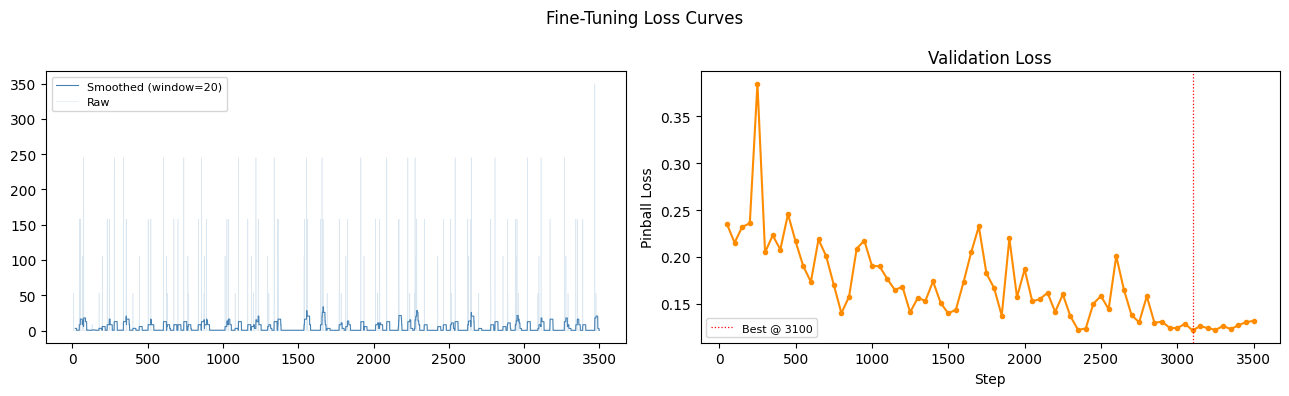

In [249]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Fine-Tuning Loss Curves')

window = 20
smoothed = pd.Series(train_losses).rolling(window).mean()
axes[0].plot(smoothed, color='steelblue', linewidth=0.8, label='Smoothed (window=20)')
axes[0].plot(train_losses, color='steelblue', alpha=0.2, linewidth=0.4, label='Raw')
axes[0].legend(fontsize=8)

if val_losses:
    vsteps, vvals = zip(*val_losses)
    axes[1].plot(vsteps, vvals, color='darkorange', marker='o', markersize=3)
    best_step = vsteps[int(np.argmin(vvals))]
    axes[1].axvline(best_step, color='red', linestyle=':', linewidth=0.9, label=f'Best @ {best_step}')
    axes[1].legend(fontsize=8)
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Pinball Loss')

plt.tight_layout()

In [251]:
ft_pred    = run_inference(pipeline, test_context, HORIZON)
ft_metrics = compute_metrics(ft_pred, test_actual)

print('fine tuned metrics:')
for k, v in ft_metrics.items():
    print(f'  {k:10s}: {v:.4f}')

fine tuned metrics:
  MAE       : 191.2139
  RMSE      : 233.0457
  MAPE(%)   : 2.3004
  MASE      : 7.6765


## Comparison

In [270]:
comparison = pd.DataFrame(
    [baseline_metrics, ft_metrics],
    index=['Baseline (Zero-Shot)', 'Fine-Tuned']
)
delta = comparison.loc['Fine-Tuned'] - comparison.loc['Baseline (Zero-Shot)']
delta_pct = (delta / comparison.loc['Baseline (Zero-Shot)'] * 100).rename('Delta (%)')
comparison = pd.concat([comparison, delta_pct.to_frame().T])

comparison

,MAE,RMSE,MAPE(%),MASE
Baseline (Zero-Shot),208.533783,253.615631,2.508856,8.371802
Fine-Tuned,191.213867,233.045746,2.300375,7.676476
Delta (%),-8.305568,-8.110654,-8.309825,-8.305568


lower delta = better results

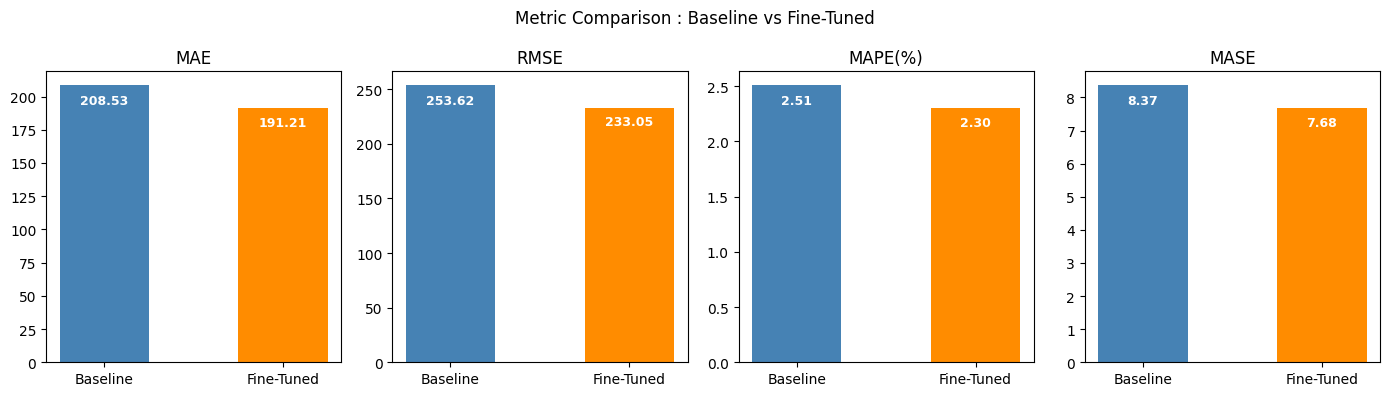

In [265]:
metrics_list = ['MAE', 'RMSE', 'MAPE(%)', 'MASE']
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle('Metric Comparison : Baseline vs Fine-Tuned', fontsize=12)

colors = ['steelblue', 'darkorange']
for ax, m in zip(axes, metrics_list):
    vals  = [baseline_metrics[m], ft_metrics[m]]
    bars  = ax.bar(['Baseline', 'Fine-Tuned'], vals, color=colors, width=0.5)
    ax.set_title(m)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 0.97,
                f'{val:.2f}', ha='center', va='top', fontsize=9,
                color='white', fontweight='bold')

plt.tight_layout()

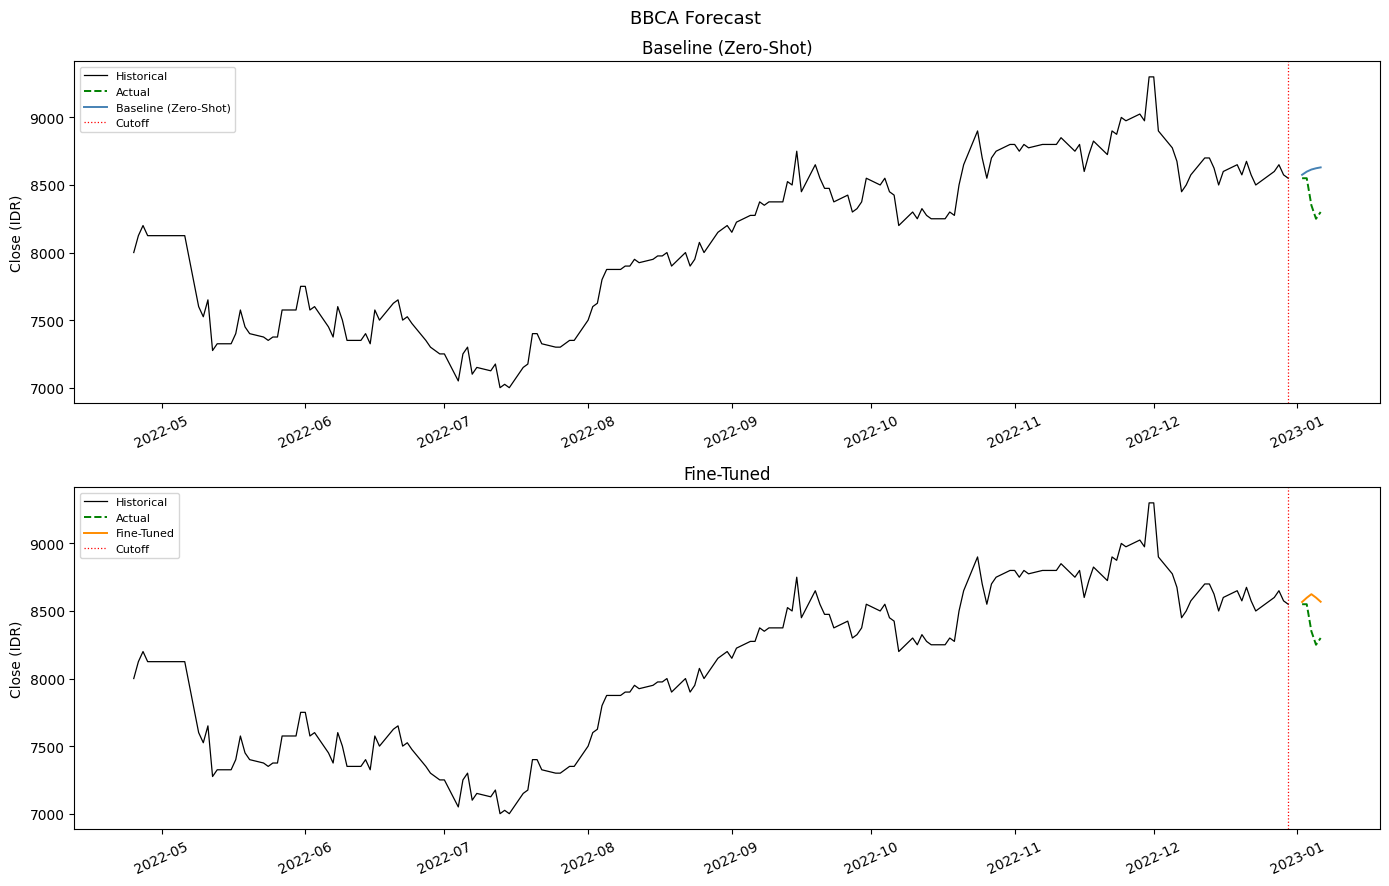

In [257]:
context_plot = train_df.iloc[-180:].copy()
context_plot['timestamp'] = pd.to_datetime(context_plot['timestamp'])
test_dates = pd.to_datetime(test_df['timestamp']).values
context_plot['close'] = np.exp(context_plot['close'])
test_actual_plot = np.exp(test_actual)
baseline_pred_plot = np.exp(baseline_pred)
ft_pred_plot = np.exp(ft_pred)
test_dates = pd.to_datetime(test_df.timestamp).values

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)
fig.suptitle('BBCA Forecast', fontsize=13)

for ax, pred, label, color in zip(
    axes,
    [baseline_pred_plot, ft_pred_plot],
    ['Baseline (Zero-Shot)', 'Fine-Tuned'],
    ['steelblue', 'darkorange']
):
    ax.plot(context_plot.timestamp, context_plot.close,
            color='black', linewidth=0.9, label='Historical')
    ax.plot(test_dates, test_actual_plot,
            color='green', linewidth=1.4, linestyle='--', label='Actual')
    ax.plot(test_dates, pred,
            color=color, linewidth=1.4, label=label)
    ax.axvline(mdates.date2num(cutoff_date), color='red', linestyle=':', linewidth=0.9, label='Cutoff')
    ax.set_title(label)
    ax.set_ylabel('Close (IDR)')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=25)

plt.tight_layout()

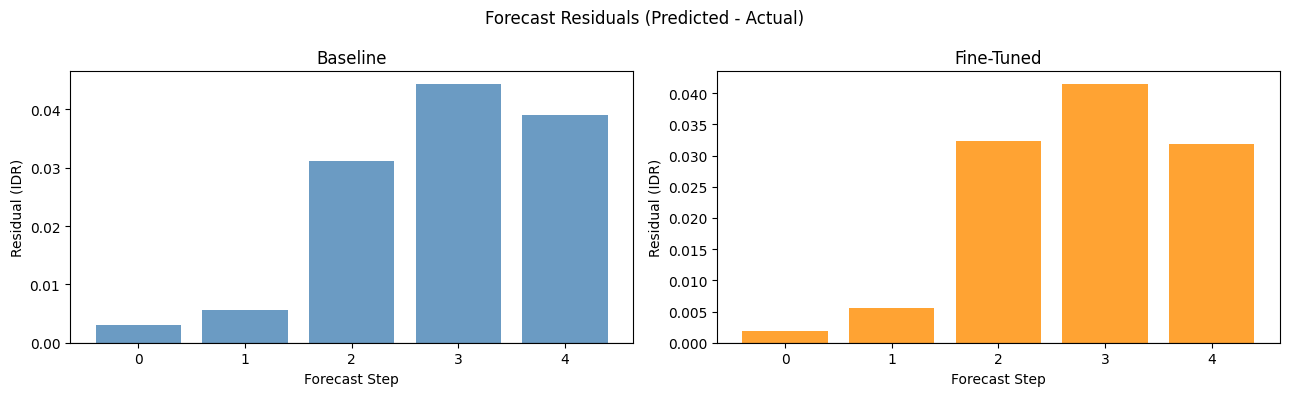

In [263]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Forecast Residuals (Predicted - Actual)', fontsize=12)

for ax, pred, label, color in zip(
    axes,
    [baseline_pred, ft_pred],
    ['Baseline', 'Fine-Tuned'],
    ['steelblue', 'darkorange']
):
    residuals = pred - test_actual
    ax.bar(range(HORIZON), residuals, color=color, alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(label)
    ax.set_xlabel('Forecast Step')
    ax.set_ylabel('Residual (IDR)')

plt.tight_layout()

In [266]:
os.makedirs(FT_MODEL_DIR, exist_ok=True)
pipeline.model.save_pretrained(FT_MODEL_DIR)
pipeline.tokenizer.save_pretrained(FT_MODEL_DIR) if hasattr(pipeline, 'tokenizer') else None
print(f'model saved {FT_MODEL_DIR}')

model saved /kaggle/working/chronos_bbca_ft


In [268]:
HF_REPO_ID='SkibidiBreaddd/BBCA-Chronos-14062026-v0'

In [269]:
from huggingface_hub import HfApi, login
from kaggle_secrets import UserSecretsClient

secret = UserSecretsClient()
hf_token = secret.get_secret('HF_TOKEN')
login(token=hf_token)

api = HfApi()
api.create_repo(repo_id=HF_REPO_ID, repo_type='model', exist_ok=True)
api.upload_folder(
    folder_path=FT_MODEL_DIR,
    repo_id=HF_REPO_ID,
    repo_type='model',
    commit_message='14-06-2026 Chronos BBCA Initial Commit '
)
print('pushedd')

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

pushedd
